# Sales Data Analysis

## Objective:
Analyze sales data to identify trends, top-performing categories,
and profit insights for better business decisions.

# Sales Data Analysis

## 1. Data Loading

## 2. Data Understanding

## 3. Data Cleaning

## 4. Feature Engineering

## 5. Monthly Sales Analysis

## 6. Day-wise Analysis

## 7. Category Analysis

## 8. Profit Analysis

## 9. Sales vs Profit Comparison

## 10. Final Insights

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
data = pd.read_csv("../data/sample.csv",encoding='latin-1')
data.head()
data.info()
data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [14]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date']= pd.to_datetime(data['Ship Date'])
data['Order Month']= data['Order Date'].dt.month
data['Order Year']= data['Order Date'].dt.year
data['Day_Number']= data['Order Date'].dt.dayofweek
data['Day_Name'] = data['Order Date'].dt.day_name()
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,Order Month,Order Year,Order day,Day number,Day name,Day_Number,Day_Name
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.9136,11,2016,8,1,Tuesday,1,Tuesday
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,11,2016,8,1,Tuesday,1,Tuesday
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,6,2016,12,6,Sunday,6,Sunday
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,10,2015,11,6,Sunday,6,Sunday
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,10,2015,11,6,Sunday,6,Sunday


## Day Wise sales analysis

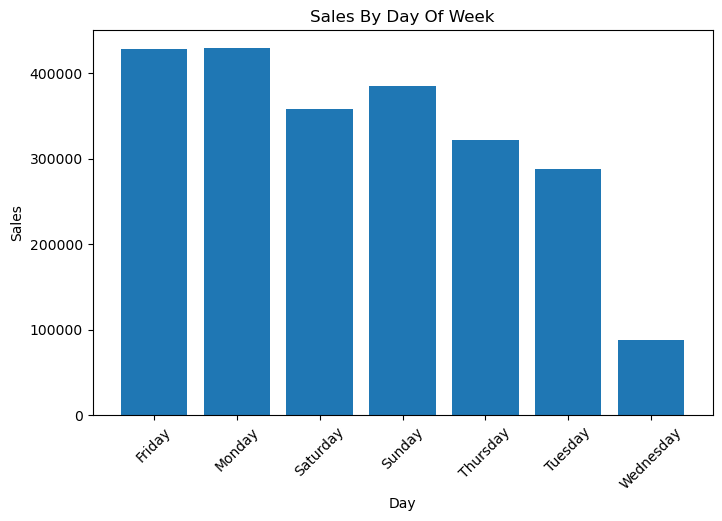

In [18]:
sales_by_day = data.groupby('Day_Name')['Sales'].sum()
plt.figure(figsize=(8,5))
plt.bar(sales_by_day.index,sales_by_day.values)
plt.title("Sales By Day Of Week")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

## Insight:
### Sales are highest on Monday and Friday,
### while mid-week (especially Wednesday) shows lower performance.

# CATEGORY ANALYSIS

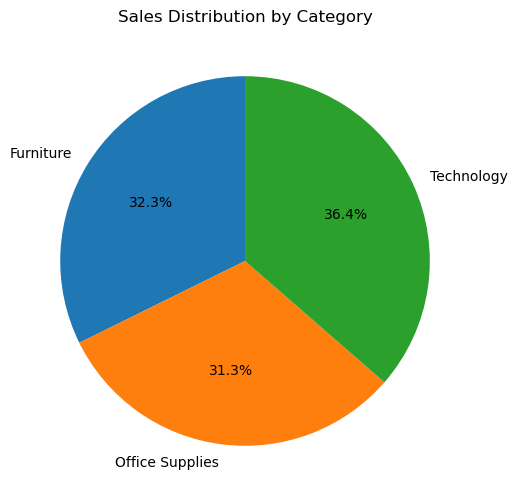

In [24]:
sales_by_category=data.groupby('Category')['Sales'].sum()
plt.figure(figsize=(6,6))
plt.pie(sales_by_category.values,labels= sales_by_category.index,autopct='%1.1f%%',
        startangle=90)
plt.title("Sales Distribution by Category")
plt.show()

# PROFIT ANALYSIS

### Group Profit by Category

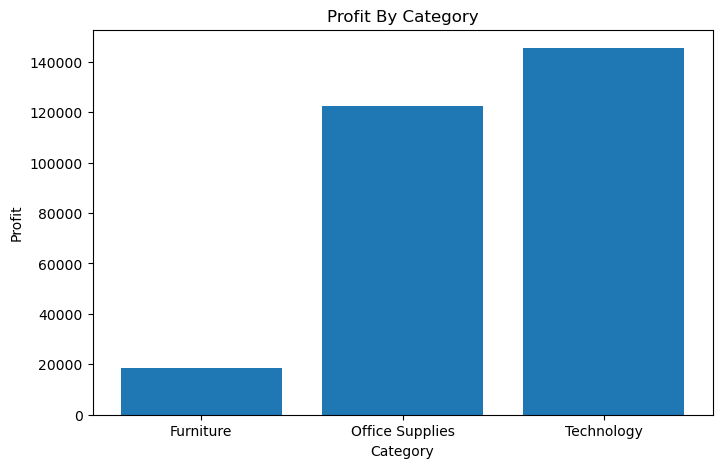

In [28]:
profit_by_category=data.groupby('Category')['Profit'].sum()
plt.figure(figsize=(8,5))
plt.bar(profit_by_category.index,profit_by_category.values)
plt.title("Profit By Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

## Insight:
### Technology category generates highest profit,
### while other categories contribute less profit.

# Sales vs Profit Comparison

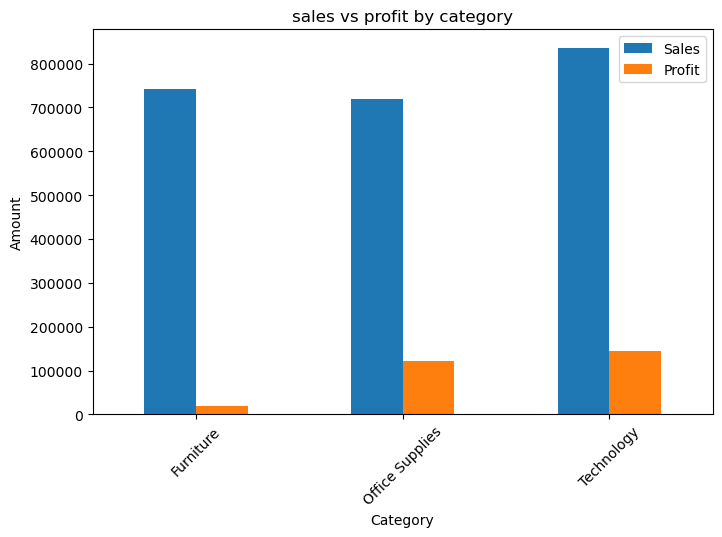

In [31]:
sales_profit = data.groupby('Category')[['Sales','Profit']].sum()
sales_profit.plot(kind= 'bar',figsize=(8,5))
plt.title("sales vs profit by category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation = 45)
plt.show()

## Final Insights

- Sales show seasonal trends with higher performance in certain months.
- Technology category contributes highest sales and profit.
- Some categories have high sales but relatively low profit margins.
- Sales patterns vary across different days of the week.
- Business should focus on high-profit categories to maximize revenue.